# Prediksi Jangka Pendek (Short-Term Forecasting)
Notebook ini difokuskan pada opsi 1: Memprediksi kondisi lalu lintas (volume kendaraan) untuk 15-60 menit ke depan menggunakan data histori yang kita miliki. Kita akan me-resample data menjadi interval 15 menit dan membuat fitur Lag (waktu sebelumnya) untuk memprediksi waktu berikutnya.

In [3]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

# 1. Memuat Data dari collected_data
data_path = '../collected_data/*.csv'
files = glob.glob(data_path)

cols = ['ID', 'Timestamp', 'Density', 'Total', 'Person', 'Car', 'Motorcycle', 'Bus', 'Truck']
df_list = []

for f in files:
    df = pd.read_csv(f, names=cols)
    df_list.append(df)

# Menggabungkan semua data
df_all = pd.concat(df_list, ignore_index=True)
df_all['Timestamp'] = pd.to_datetime(df_all['Timestamp'])

# Mengurutkan berdasarkan waktu (Time-Series harus urut waktu)
df_all = df_all.sort_values('Timestamp').reset_index(drop=True)

print(f"Total baris data mentah: {len(df_all)}")
df_all.head()

Total baris data mentah: 84689


,ID,Timestamp,Density,Total,Person,Car,Motorcycle,Bus,Truck
0,1,2026-05-28 06:03:01.551126,Empty,6,0,2,3,1,0
1,2,2026-05-28 06:03:06.684782,Empty,2,0,2,0,0,0
2,3,2026-05-28 06:03:11.973533,Empty,2,0,1,1,0,0
3,4,2026-05-28 06:03:14.876258,Empty,5,1,3,1,0,0
4,5,2026-05-28 06:03:20.706881,Empty,3,0,2,0,0,1


In [4]:
# 2. Resampling Data ke Interval 15 Menit
# Karena data dicatat setiap ~5 detik, kita akan mengambil rata-rata jumlah kendaraan per 15 menit.
df_all.set_index('Timestamp', inplace=True)

# Resample rata-rata per 15 menit
df_resampled = df_all[['Total', 'Car', 'Motorcycle']].resample('15T').mean()

# Jika ada jam yang kosong (tidak ada rekaman), kita isi dengan interpolasi atau ffill
df_resampled = df_resampled.interpolate(method='linear')
df_resampled = df_resampled.dropna()

print(f"Total baris setelah resample 15 menit: {len(df_resampled)}")
df_resampled.head()

Total baris setelah resample 15 menit: 594


,Total,Car,Motorcycle
Timestamp,,,
2026-05-28 06:00:00,4.827815,2.245033,1.940397
2026-05-28 06:15:00,5.131148,2.535519,1.825137
2026-05-28 06:30:00,4.214286,2.225275,1.362637
2026-05-28 06:45:00,4.782123,2.312849,1.681564
2026-05-28 07:00:00,4.744565,2.472826,1.538043


In [5]:
# 3. Membuat Fitur Lag (Jendela Waktu ke Belakang)
# Kita akan memprediksi 'Total' kendaraan di waktu T
# berdasarkan 'Total' di T-1 (15 mnt lalu), T-2 (30 mnt lalu), dan T-3 (45 mnt lalu).

df_features = df_resampled.copy()

df_features['Lag_1'] = df_features['Total'].shift(1)  # 15 menit lalu
df_features['Lag_2'] = df_features['Total'].shift(2)  # 30 menit lalu
df_features['Lag_3'] = df_features['Total'].shift(3)  # 45 menit lalu
df_features['Lag_4'] = df_features['Total'].shift(4)  # 60 menit lalu

# Menambah fitur waktu untuk membantu model mengenali pola harian
df_features['Hour'] = df_features.index.hour
df_features['Minute'] = df_features.index.minute
df_features['DayOfWeek'] = df_features.index.dayofweek

# Hapus baris yang mengandung NaN akibat fungsi shift
df_features = df_features.dropna()

df_features.head()

,Total,Car,Motorcycle,Lag_1,Lag_2,Lag_3,Lag_4,Hour,Minute,DayOfWeek
Timestamp,,,,,,,,,,
2026-05-28 07:00:00,4.744565,2.472826,1.538043,4.782123,4.214286,5.131148,4.827815,7,0,3
2026-05-28 07:15:00,4.254144,2.093923,1.596685,4.744565,4.782123,4.214286,5.131148,7,15,3
2026-05-28 07:30:00,5.049180,2.650273,1.786885,4.254144,4.744565,4.782123,4.214286,7,30,3
2026-05-28 07:45:00,4.554945,2.615385,1.554945,5.049180,4.254144,4.744565,4.782123,7,45,3
2026-05-28 08:00:00,6.191257,3.540984,2.065574,4.554945,5.049180,4.254144,4.744565,8,0,3


In [6]:
# 4. Membagi Data (Train dan Test)
# Karena ini time-series, kita tidak boleh mengacak secara random (train_test_split biasa dengan shuffle=True).
# Kita gunakan urutan waktu. Misalnya 80% data pertama untuk Train, 20% terakhir untuk Test.

X = df_features[['Lag_1', 'Lag_2', 'Lag_3', 'Lag_4', 'Hour', 'Minute', 'DayOfWeek']]
y = df_features['Total']

split_idx = int(len(df_features) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Ukuran Train: {len(X_train)}")
print(f"Ukuran Test: {len(X_test)}")

Ukuran Train: 472
Ukuran Test: 118


In [7]:
# 5. Melatih Model Machine Learning (Random Forest)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluasi
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f} kendaraan")
print("Artinya, prediksi kita rata-rata meleset sekitar {:.2f} kendaraan dari kondisi aslinya.".format(mae))

Mean Absolute Error (MAE): 0.62 kendaraan
Artinya, prediksi kita rata-rata meleset sekitar 0.62 kendaraan dari kondisi aslinya.


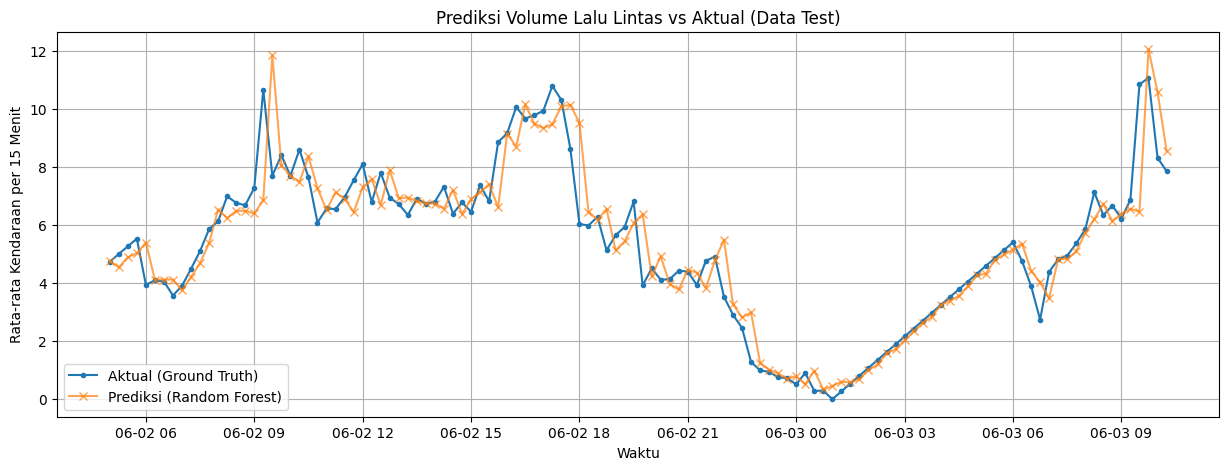

In [8]:
# 6. Visualisasi Hasil Prediksi
plt.figure(figsize=(15, 5))
plt.plot(y_test.index, y_test.values, label='Aktual (Ground Truth)', marker='.')
plt.plot(y_test.index, y_pred, label='Prediksi (Random Forest)', marker='x', alpha=0.7)
plt.title('Prediksi Volume Lalu Lintas vs Aktual (Data Test)')
plt.xlabel('Waktu')
plt.ylabel('Rata-rata Kendaraan per 15 Menit')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
# 7. Simulasi Prediksi 15 Menit Kedepan dari Kondisi "Sekarang"
# Anggap data_terakhir adalah kondisi jalanan saat ini.

data_terakhir = df_features.iloc[-1:]

print("Kondisi Terakhir (Saat ini):")
print(data_terakhir[['Total', 'Hour', 'Minute']])

# Untuk memprediksi 15 menit KE DEPAN, nilai lag akan bergeser.
fitur_selanjutnya = pd.DataFrame({
    'Lag_1': [data_terakhir['Total'].values[0]],
    'Lag_2': [data_terakhir['Lag_1'].values[0]],
    'Lag_3': [data_terakhir['Lag_2'].values[0]],
    'Lag_4': [data_terakhir['Lag_3'].values[0]],
    'Hour': [(data_terakhir.index[-1] + pd.Timedelta(minutes=15)).hour],
    'Minute': [(data_terakhir.index[-1] + pd.Timedelta(minutes=15)).minute],
    'DayOfWeek': [(data_terakhir.index[-1] + pd.Timedelta(minutes=15)).dayofweek]
})

prediksi_depan = model.predict(fitur_selanjutnya)

print("\n--- PREDIKSI ---")
waktu_depan = data_terakhir.index[-1] + pd.Timedelta(minutes=15)
print(f"Prediksi rata-rata kendaraan pada {waktu_depan.strftime('%Y-%m-%d %H:%M')} adalah: {prediksi_depan[0]:.2f}")

Kondisi Terakhir (Saat ini):
                        Total  Hour  Minute
Timestamp                                  
2026-06-03 10:15:00  7.846154    10      15

--- PREDIKSI ---
Prediksi rata-rata kendaraan pada 2026-06-03 10:30 adalah: 7.72


In [10]:
import joblib
joblib.dump(model, 'rf_traffic_model.pkl')


['rf_traffic_model.pkl']